<a href="https://colab.research.google.com/github/Xyrfo/Pembelajaran-Mesin/blob/main/JS06/tugas_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab JS06 - Support Vector Machine

## Bagian 1 - SVM pada voice.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

### Langkah 1 - Load Data

In [2]:
uploaded = files.upload()
voice = pd.read_csv(next(iter(uploaded)))

label_candidates = [c for c in voice.columns if c.lower() in ['label', 'gender', 'jenis_kelamin']]
label_col = label_candidates[0] if label_candidates else voice.columns[-1]

voice = voice.dropna()
X_voice = voice.drop(columns=[label_col]).select_dtypes(include=np.number)
encoder = LabelEncoder()
y_voice = encoder.fit_transform(voice[label_col].astype(str))

print('Kolom label:', label_col)
print('Jumlah fitur:', X_voice.shape[1])
print('Distribusi label:')
print(voice[label_col].value_counts())

Saving voice.csv to voice.csv
Kolom label: label
Jumlah fitur: 20
Distribusi label:
label
male      1584
female    1584
Name: count, dtype: int64


### Langkah 2 - Split Data dan Pelatihan Model

Setiap kombinasi rasio split (70:30 dan 80:20) dan kernel (linier, polynomial, RBF) dilatih dan dievaluasi dengan metrik akurasi.

Standardisasi (`StandardScaler`) digunakan karena SVM sensitif terhadap skala fitur dan fitur akustik pada `voice.csv` memiliki rentang nilai yang berbeda-beda.

In [3]:
hasil_voice = []

for rasio in [0.30, 0.20]:
    X_train, X_test, y_train, y_test = train_test_split(
        X_voice, y_voice, test_size=rasio, random_state=42, stratify=y_voice
    )

    for kernel in ['linear', 'poly', 'rbf']:
        model = make_pipeline(StandardScaler(), SVC(kernel=kernel))
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        hasil_voice.append({
            'Split': f'{int((1 - rasio) * 100)}:{int(rasio * 100)}',
            'Kernel': kernel,
            'Akurasi': accuracy_score(y_test, pred)
        })

hasil_voice = pd.DataFrame(hasil_voice)
display(hasil_voice.round(4))

,Split,Kernel,Akurasi
0,70:30,linear,0.9790
1,70:30,poly,0.9600
2,70:30,rbf,0.9832
3,80:20,linear,0.9748
4,80:20,poly,0.9558
5,80:20,rbf,0.9826


### Langkah 3 - Tabulasi Performansi

Tabulasikan performansi setiap split dan kernel berdasarkan metrik akurasi.

Split,70:30,80:20
Kernel,,
linear,0.9790,0.9748
poly,0.9600,0.9558
rbf,0.9832,0.9826


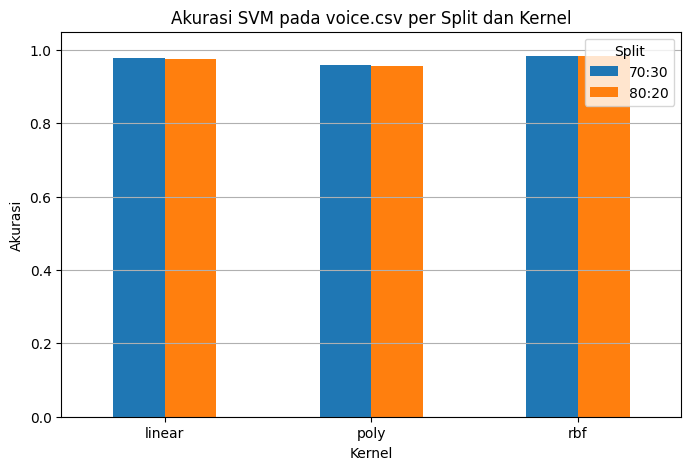

Kombinasi terbaik: Split 70:30 dengan kernel rbf
Akurasi: 0.9832


In [4]:
tabel = hasil_voice.pivot(index='Kernel', columns='Split', values='Akurasi')
display(tabel.round(4))

tabel.plot(kind='bar', ylim=(0, 1.05), figsize=(8, 5))
plt.title('Akurasi SVM pada voice.csv per Split dan Kernel')
plt.ylabel('Akurasi')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

terbaik = hasil_voice.loc[hasil_voice['Akurasi'].idxmax()]
print(f"Kombinasi terbaik: Split {terbaik['Split']} dengan kernel {terbaik['Kernel']}")
print(f"Akurasi: {terbaik['Akurasi']:.4f}")

## Bagian 2 - SVM Siang dan Malam dengan Fitur Histogram

In [5]:
import os, shutil, zipfile
import cv2
import matplotlib.image as mpimg
from pathlib import Path

zip_upload = files.upload()
zip_name = next(iter(zip_upload))
extract_dir = 'day_night_images'

# Bersihkan folder lama agar tidak ada sisa struktur dari ekstraksi sebelumnya
shutil.rmtree(extract_dir, ignore_errors=True)
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_name) as z:
    z.extractall(extract_dir)

# Tampilkan struktur folder hasil ekstraksi untuk verifikasi
print('Struktur folder hasil ekstraksi:')
for root, dirs, filenames in os.walk(extract_dir):
    print(f'  {root} -> {len(filenames)} file')

Saving images.zip to images.zip
Struktur folder hasil ekstraksi:
  day_night_images -> 0 file
  day_night_images/images -> 0 file
  day_night_images/images/training -> 0 file
  day_night_images/images/training/night -> 120 file
  day_night_images/images/training/day -> 120 file
  day_night_images/images/test -> 0 file
  day_night_images/images/test/night -> 80 file
  day_night_images/images/test/day -> 80 file
  day_night_images/__MACOSX -> 1 file
  day_night_images/__MACOSX/images -> 2 file
  day_night_images/__MACOSX/images/training -> 2 file
  day_night_images/__MACOSX/images/training/night -> 120 file
  day_night_images/__MACOSX/images/training/day -> 120 file
  day_night_images/__MACOSX/images/test -> 2 file
  day_night_images/__MACOSX/images/test/night -> 80 file
  day_night_images/__MACOSX/images/test/day -> 80 file


### Langkah 1 - Load Data dan Visualisasi

Fungsi `load_dataset` mengikuti gaya Lab 5.

Jumlah gambar: 400
Shape	: (889, 1280, 3)
Label	: day


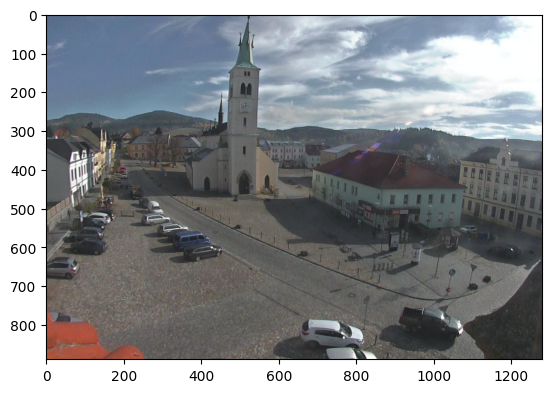

In [8]:
IMAGE_EXT = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

def find_class_from_path(path):
    for part in reversed(Path(path).parts):
        low = part.lower()
        if low in ['day', 'siang']:
            return 'day'
        if low in ['night', 'malam']:
            return 'night'
    return None

def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []

    for file in p.rglob('*'):
        if not file.is_file():
            continue
        # Lewati metadata macOS
        if '__MACOSX' in file.parts or file.name.startswith('._'):
            continue
        if file.suffix.lower() not in IMAGE_EXT:
            continue

        label = find_class_from_path(file)
        if label is None:
            continue

        try:
            img = mpimg.imread(str(file))
            if img is not None:
                img_list.append((img, label))
        except Exception:
            continue

    return img_list

def random_img_viz(img_list):
    if len(img_list) == 0:
        print('Error: Dataset kosong, tidak ada gambar untuk ditampilkan!')
        return
    rand_num = np.random.randint(0, len(img_list))
    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

train_img = load_dataset(extract_dir)
print('Jumlah gambar:', len(train_img))

if len(train_img) == 0:
    print('Dataset kosong. Pastikan ZIP berisi folder day/night (atau siang/malam).')
    for root, dirs, filenames in os.walk(extract_dir):
        print(f'  {root} -> {len(filenames)} file, subfolder: {dirs}')
else:
    random_img_viz(train_img)

### Langkah 2 - Pra Pengolahan Data

In [9]:
def standarized_input(image):
    # resize to w: 1100, h: 600
    std_img = cv2.resize(image, (1100, 600))
    return std_img

def label_encoder(label):
    # day as 1; night as 0
    num_val = 0
    if label.lower() in ['day', 'siang']:
        num_val = 1
    return num_val

def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        std_img = standarized_input(image)
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

train_std_img_list = preprocess(train_img)
print('Jumlah data setelah pra pengolahan:', len(train_std_img_list))
if len(train_std_img_list) > 0:
    print('Contoh shape:', train_std_img_list[0][0].shape)
else:
    print('Tidak ada data untuk diproses. Periksa kembali isi ZIP dataset.')

Jumlah data setelah pra pengolahan: 400
Contoh shape: (600, 1100, 3)


### Langkah 3 - Ekstraksi Fitur Histogram

In [10]:
def histogram_feature(image, bins=32):
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    features = []
    for channel in range(3):
        hist = np.histogram(image[:, :, channel], bins=bins, range=(0, 255), density=True)[0]
        features.extend(hist)
    return np.array(features)

def extract_histogram_feature(img_list):
    feat_list = []
    labels = []

    for img in img_list:
        img_feat = histogram_feature(img[0])
        img_label = img[1]

        feat_list.append(img_feat)
        labels.append(img_label)

    data = np.column_stack((feat_list, labels))
    df = pd.DataFrame(data)

    return df

train_hist = extract_histogram_feature(train_std_img_list)
print(f'Shape: {train_hist.shape}')
train_hist.head()

Shape: (400, 97)


,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
0,0.066778,0.030032,0.008445,0.005452,0.003136,0.001799,0.001349,0.001064,0.000892,0.000751,...,0.000096,0.000109,0.000097,0.000091,0.000092,0.000081,0.000079,0.000127,0.000408,0.0
1,0.001545,0.016037,0.035704,0.034621,0.020685,0.004598,0.001668,0.001194,0.000985,0.000798,...,0.000016,0.000016,0.000018,0.000018,0.000023,0.000021,0.000019,0.000013,0.000010,0.0
2,0.021854,0.062510,0.021996,0.005421,0.002412,0.001762,0.001525,0.001254,0.001118,0.001013,...,0.000021,0.000023,0.000020,0.000026,0.000026,0.000028,0.000029,0.000022,0.000018,0.0
3,0.080522,0.008799,0.003972,0.002804,0.002485,0.002450,0.002699,0.002857,0.002804,0.002555,...,0.000109,0.000089,0.000075,0.000075,0.000064,0.000059,0.000060,0.000086,0.000293,0.0
4,0.001888,0.006335,0.010683,0.013354,0.014795,0.014786,0.013731,0.012119,0.010010,0.007727,...,0.000018,0.000014,0.000012,0.000009,0.000008,0.000004,0.000003,0.000004,0.000003,0.0


### Langkah 4 - Split 80:20

Pisahkan fitur dan label, lalu bagi data dengan rasio 80:20.

In [11]:
X = train_hist.iloc[:, :-1].values
y = train_hist.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Data training:', X_train.shape)
print('Data testing :', X_test.shape)

Data training: (320, 96)
Data testing : (80, 96)


### Langkah 5 - Model SVM Kernel RBF dan Hyperparameter Tunning

Model memakai `SVC(kernel='rbf')`. Hyperparameter `C` dan `gamma` dicari dengan `GridSearchCV`.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print('Parameter terbaik:', grid.best_params_)
print('Akurasi validasi silang:', round(grid.best_score_, 4))

Parameter terbaik: {'svc__C': 1, 'svc__gamma': 'scale'}
Akurasi validasi silang: 0.9875


### Langkah 6 - Evaluasi

Catat performansi akurasi pada data training dan testing.

In [13]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train:.4f}')
print(f'Accuracy on test : {acc_test:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['night/malam', 'day/siang']))

Accuracy on train: 0.9969
Accuracy on test : 1.0000

              precision    recall  f1-score   support

 night/malam       1.00      1.00      1.00        40
   day/siang       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## Kesimpulan

1. **Bagian 1:** Dari enam kombinasi (2 rasio split x 3 kernel), kombinasi dengan akurasi tertinggi adalah yang ditampilkan oleh cell ringkasan. Kernel RBF umumnya unggul pada `voice.csv` karena hubungan antarfitur tidak selalu linier.
2. **Bagian 2:** SVM kernel RBF dengan fitur histogram warna mampu membedakan citra siang dan malam. Nilai `C` dan `gamma` terbaik diperoleh melalui GridSearchCV, dan akurasi training serta testing dicatat pada cell evaluasi.